In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
import numpy as np

%store -r parameters
%store -r mean_regs
%store -r ind_regs
%store -r ind_regs_fe
%store -r ind_regs_fe2
%store -r ar_1


os.chdir('/Users/fogellmcmuffin/Documents/thesis/_replication/')    # Working dir

mean_spf_trim = pd.read_csv('cleaned_data/mean_spf_trim.csv')
ind_spf_trim = pd.read_csv('cleaned_data/ind_spf_trim.csv')
vintage_trim = pd.read_csv('cleaned_data/vintage_trim.csv')

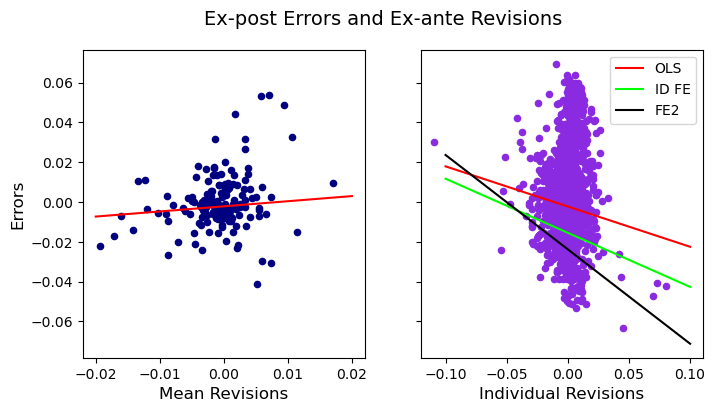

In [11]:
#####################
 ## Rev & Errors ##
#####################

fig, (axm, axi) = plt.subplots(nrows=1, sharey=True, ncols=2, figsize=(8, 4))
fig.suptitle('Ex-post Errors and Ex-ante Revisions', fontsize=14)

xm = mean_spf_trim['r_t3'][1:]
ym = mean_spf_trim['e_t3'][1:]

axm.scatter(xm, ym, c='navy', alpha=1, s=20)
model_m = mean_regs[3].params[0] + mean_regs[3].params[1] * np.linspace(-0.02, 0.02)
axm.plot(np.linspace(-0.02, 0.02),  model_m, color='red', lw=1.5)

axm.set_xlabel('Mean Revisions', fontsize=12)
axm.set_ylabel('Errors', fontsize=12)

### Individual ###
xi = ind_spf_trim['r_t3']
yi = ind_spf_trim['e_t3']
model_p = ind_regs[3].params[0] + ind_regs[3].params[1] * np.linspace(-0.1, 0.1)
model_fe = ind_regs_fe[3].params[0] + ind_regs_fe[3].params[1] * np.linspace(-0.1, 0.1)
model_fe2 = ind_regs_fe2[3].params[0] + ind_regs_fe2[3].params[1] * np.linspace(-0.1, 0.1)

axi.scatter(xi, yi, c='blueviolet', alpha=1, s=20)
axi.plot(np.linspace(-0.1, 0.1), model_p, label='OLS', color='red', lw=1.5)
axi.plot(np.linspace(-0.1, 0.1), model_fe, label='ID FE', color='lime', lw=1.5)
axi.plot(np.linspace(-0.1, 0.1), model_fe2, label='FE2', color='black', lw=1.5)

axi.set_xlabel('Individual Revisions', fontsize=12)
axi.legend()

plt.show()
fig.savefig('output/figures/re_scat.png', dpi=200)
fig.savefig('/Users/fogellmcmuffin/Documents/thesis/drafts/latex_draft/figs_n_tables/re_scat.png', dpi=200)

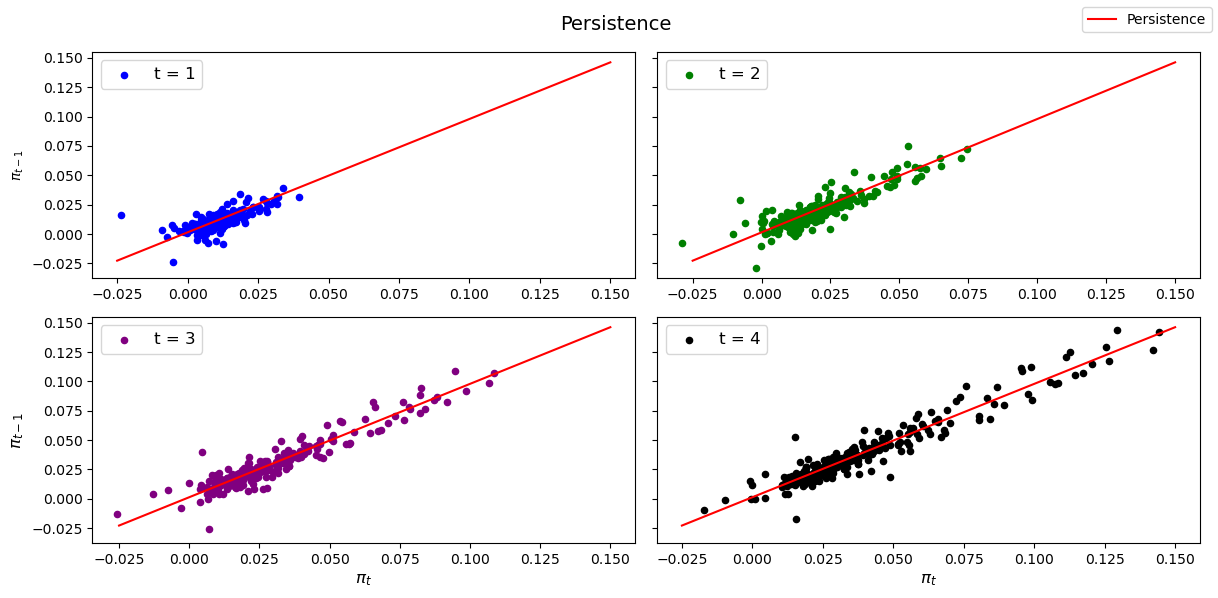

In [12]:
#####################
  ## Autoregg. ##
#####################
vintage_trim = pd.read_csv('cleaned_data/vintage_trim.csv')
vintage_trim = vintage_trim.set_index(pd.to_datetime(vintage_trim['DATE']))

vintage_trim = vintage_trim.loc[(vintage_trim['DATE'] >= '1965-06-30') & (vintage_trim['DATE'] <= '2022-12-31')]
vintage_trim = vintage_trim[['t0', 't1', 't2', 't3', 't4', 'rec']]

model0 = ar_1.params[0] + ar_1.params[1] * np.linspace(-0.025, 0.150)

fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(nrows=2, ncols=2, figsize=(12, 6), sharey=True,)
fig.suptitle('Persistence', fontsize=14)

ax0.scatter(vintage_trim['t0']['1965-09-30':], vintage_trim['t0'].shift(1)['1965-09-30':], c='blue', label=r't = 1', alpha=1, s=20)
ar = ax0.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5, label='Persistence')
ax0.set_ylabel(r'$\pi_{t-1}$', fontsize=10)
ax0.legend(['t = 1'], fontsize=12)

ax1.scatter(vintage_trim['t1']['1965-09-30':], vintage_trim['t1'].shift(1)['1965-09-30':], c='green', label='t = 2', alpha=1, s=20)
ax1.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5)
ax1.legend(['t = 2'], fontsize=12)

ax2.scatter(vintage_trim['t2']['1965-09-30':], vintage_trim['t2'].shift(1)['1965-09-30':], c='purple', label='t = 3', alpha=1, s=20)
ax2.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5)
ax2.set_ylabel(r'$\pi_{t-1}$', fontsize=12)
ax2.set_xlabel(r'$\pi_t$', fontsize=12)
ax2.legend(['t = 3'], fontsize=12)

ax3.scatter(vintage_trim['t3']['1965-09-30':], vintage_trim['t3'].shift(1)['1965-09-30':], c='black', label='t = 4', alpha=1, s=20)
ax3.plot(np.linspace(-0.025, 0.150), model0, color="red", lw=1.5)
ax3.set_xlabel(r'$\pi_t$', fontsize=12)
ax3.legend(['t = 4'], fontsize=12)

fig.legend(handles=ar)
plt.tight_layout()
plt.show()
fig.savefig('output/figures/ar_scat.png', dpi=200)
fig.savefig('/Users/fogellmcmuffin/Documents/thesis/drafts/latex_draft/figs_n_tables/ar_scat.png', dpi=200)

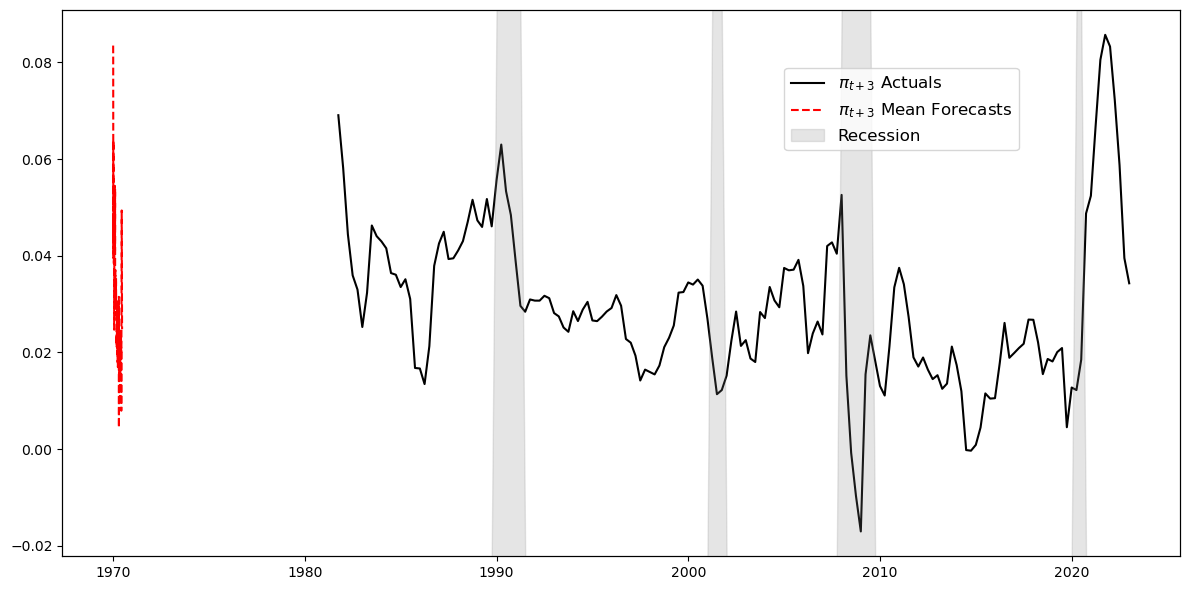

In [13]:
#####################
## Actuals vs Mean ##
#####################
vintage_trim = pd.read_csv('cleaned_data/vintage_trim.csv')
vintage_trim['DATE'] = pd.to_datetime(vintage_trim['DATE'])
vintage_trim = vintage_trim.loc[(vintage_trim['DATE'] >= '1981-09-01') & (vintage_trim['DATE'] <= '2022-12-31')]  # Filter data
vintage_trim = vintage_trim.set_index('DATE')

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Plot actuals and forecasts
ax.plot(vintage_trim.index, vintage_trim['t3'], color="k", lw=1.5, label=r'$\pi_{t+3}$ Actuals')
ax.plot(mean_spf_trim.index, mean_spf_trim['f_t3'], color='red', linestyle='dashed', lw=1.5, label=r'$\pi_{t+3}$ Mean Forecasts')

# Add recession shading
ax1 = ax.twinx()
ax1.fill_between(vintage_trim.index, 0, vintage_trim['rec'], color='grey', alpha=0.2, label='Recession')
ax1.set_ylim(0, 1)
ax1.get_yaxis().set_visible(False)

# Legend and formatting
fig.legend(loc='right', fontsize=12, bbox_to_anchor=(0.76, 0.75, 0.1, 0.12))
plt.tight_layout()
plt.show()
fig.savefig('output/figures/act_errors_line.png', dpi=200)
fig.savefig('/Users/fogellmcmuffin/Documents/thesis/drafts/latex_draft/figs_n_tables/act_errors_line.png', dpi=200)

KeyError: 'The `start` argument could not be matched to a location related to the index of the data.'

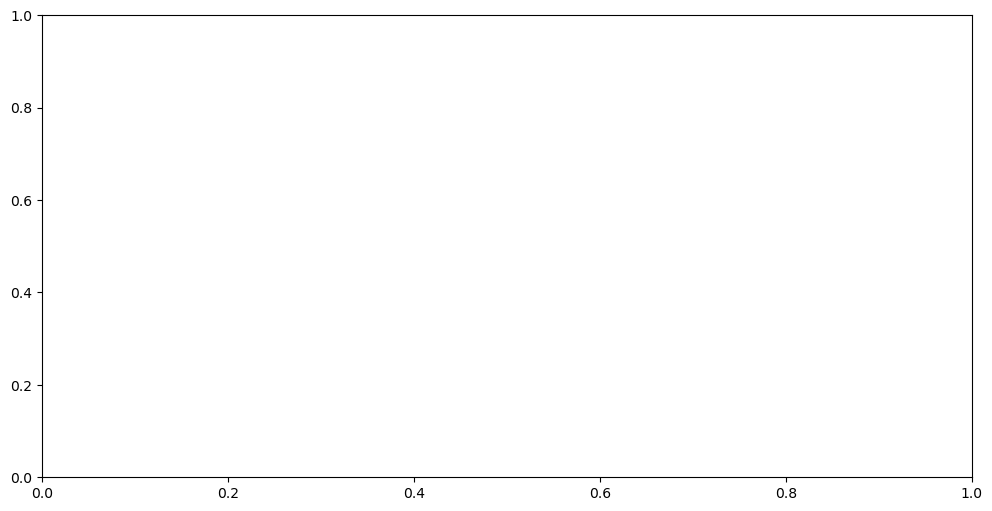

In [14]:
#####################
     ## Models ##
#####################
# FIRE Model
fig, ax = plt.subplots(figsize=(12, 6))

# Generate AR(1) predictions
ar_predictions = ar_1.predict(start=vintage_trim.index[0], end=vintage_trim.index[-1])
ax.plot(vintage_trim.index, ar_predictions, color='blue', lw=1.5, label='FIRE')

ax.plot(mean_spf_trim.index, mean_spf_trim['f_t3'], color='red', linestyle='dashed', lw=1.5, label=r'$\pi_{t+3}$ Mean Forecasts')

ax1 = ax.twinx()
ax1.fill_between(vintage_trim.index, 0, vintage_trim['rec'], color='grey', alpha=0.2, label='Recession')
ax1.set_ylim(0, 1)
ax1.get_yaxis().set_visible(False)


fig.legend(loc='right', fontsize=12, bbox_to_anchor=(0.76, 0.75, 0.1, 0.12))
plt.tight_layout()
plt.show()